In [1]:
import os
from pathlib import Path
os.chdir(Path(os.getcwd()).parent)

In [2]:
import os
import time
import pandas as pd
import cvxpy as cp
from pathlib import Path
from Code.Plotting import DPhil_Plotting
from Code.Network.Network import Network_STEVFNs

case_study_name = "SG-VN_Collab"

base_folder = Path(os.getcwd())
data_folder = os.path.join(base_folder, "Data")
case_study_folder = os.path.join(data_folder, "Case_Study", case_study_name)
scenario_folders_list = [x[0] for x in os.walk(case_study_folder)][1:]
network_structure_filename = os.path.join(case_study_folder, "Network_Structure.csv")
results_filename = os.path.join(case_study_folder, "total_data.csv")
website_total_data_filename = os.path.join(case_study_folder, "total_data_unrounded.csv")
capacities_filename = os.path.join(case_study_folder, "capacities_total_data.csv")
unrounded_results_filename = os.path.join(case_study_folder, "internal_total_data.csv")

network_structure_df = pd.read_csv(network_structure_filename)

print("========================== Building ==========================")
start_time0 = time.time()
my_network = Network_STEVFNs()
my_network.build(network_structure_df)
end_time = time.time()
print("Time taken to build network = ", end_time - start_time0, "s")

results = list()
for counter1 in range(len(scenario_folders_list)):

    scenario_folder = scenario_folders_list[-1-counter1]
    asset_parameters_filename = os.path.join(scenario_folder, "Asset_Parameters.csv")
    location_parameters_filename = os.path.join(scenario_folder, "Location_Parameters.csv")
    system_parameters_filename = os.path.join(scenario_folder, "System_Parameters.csv")

    asset_parameters_df = pd.read_csv(asset_parameters_filename)
    location_parameters_df = pd.read_csv(location_parameters_filename)
    system_parameters_df = pd.read_csv(system_parameters_filename)
    my_network.scenario_name = os.path.basename(scenario_folder)

    print(f"\n================== Updating for Scenario {my_network.scenario_name} ==================\n")
    start_time = time.time()
    my_network.update(location_parameters_df, asset_parameters_df, system_parameters_df)
    end_time = time.time()
    print("Time taken to update network = ", end_time - start_time, "s")

    start_time = time.time()
    solver_name = "CLARABEL"
    if solver_name == "CLARABEL":
        my_network.problem.solve(solver=cp.CLARABEL, max_iter=10000, ignore_dpp=True)
    elif solver_name == "MOSEK":
        my_network.problem.solve(solver=cp.MOSEK, ignore_dpp=True)
    else:
        raise ValueError(f"Unknown solver: {solver_name}")
    end_time = time.time()

    print(f"----------------- Scenario {my_network.scenario_name} Main Results ----------------------\n")
    print("Time taken to solve problem = ", end_time - start_time, "s")
    print(my_network.problem.solution.status) # type: ignore
    if my_network.problem.value == float("inf"):
        continue
    print("Total cost to satisfy all demand = ", my_network.problem.value, " Billion USD")
    print("Total emissions = ", my_network.assets[0].asset_size(), "MtCO2e")

    artist = DPhil_Plotting.plot_asset_sizes(my_network)
    results.append({
        "uid": f"S-{my_network.scenario_name}",
        "cost": my_network.problem.value,
        "emissions": my_network.assets[0].asset_size(),
        "artist": artist
    })

========================== Building ==========================


/home/jpacilo/Developer/ce2m/STEVFNs/.venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #0 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "


Time taken to build network =  17.580748081207275 s

================== Updating for Scenario 30 ==================

Time taken to update network =  0.0719919204711914 s


/home/jpacilo/Developer/ce2m/STEVFNs/.venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #0 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "
/home/jpacilo/Developer/ce2m/STEVFNs/.venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #40 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "
/home/jpacilo/Developer/ce2m/STEVFNs/.venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #70 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "


----------------- Scenario 30 Main Results ----------------------

Time taken to solve problem =  14.768725395202637 s
optimal
Total cost to satisfy all demand =  547.877044779412  Billion USD
Total emissions =  877.5493843625316 MtCO2e

================== Updating for Scenario 0 ==================

Time taken to update network =  0.06544637680053711 s


...

----------------- Scenario 70 Main Results ----------------------

Time taken to solve problem =  15.046616315841675 s
optimal
Total cost to satisfy all demand =  499.05737126905376  Billion USD
Total emissions =  1760.0000426952413 MtCO2e

================== Updating for Scenario 20 ==================

Time taken to update network =  0.06743407249450684 s


/home/jpacilo/Developer/ce2m/STEVFNs/.venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #0 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "
/home/jpacilo/Developer/ce2m/STEVFNs/.venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #40 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "
/home/jpacilo/Developer/ce2m/STEVFNs/.venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #70 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "


----------------- Scenario 20 Main Results ----------------------

Time taken to solve problem =  14.195333480834961 s
optimal
Total cost to satisfy all demand =  553.5791894289812  Billion USD
Total emissions =  824.8119297741864 MtCO2e

================== Updating for Scenario 80 ==================

Time taken to update network =  0.07238888740539551 s


/home/jpacilo/Developer/ce2m/STEVFNs/.venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #0 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "
/home/jpacilo/Developer/ce2m/STEVFNs/.venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #40 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "
/home/jpacilo/Developer/ce2m/STEVFNs/.venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #70 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "


----------------- Scenario 80 Main Results ----------------------

Time taken to solve problem =  15.0184965133667 s
optimal
Total cost to satisfy all demand =  495.234089920364  Billion USD
Total emissions =  1920.0000250585977 MtCO2e


In [3]:
feature = "EL_Transport"

df_results = pd.DataFrame(results)
df_results["EL_Transport"] = df_results.artist.apply(lambda x: x.bar_data_dict[feature]["height"][0])
df_results.drop(columns="artist").to_csv(f"{case_study_name}__{feature}.csv", index=False)

In [4]:
df_results.drop(columns="artist")

,uid,cost,emissions,EL_Transport
0,S-30,547.877045,877.549384,14.639983
1,S-0,649.190907,274.937348,15.748657
2,S-10,592.477587,549.874620,15.046914
3,S-60,502.347416,1650.000037,13.308482
4,S-40,528.915620,1100.000076,14.134250
5,S-BAU,785.371565,0.000260,14.148412
6,S-90,489.796769,2200.000031,11.634657
7,S-50,514.061702,1370.000066,13.575044
8,S-70,499.057371,1760.000043,12.648508
9,S-20,553.579189,824.811930,14.731891


In [5]:
df_results = df_results.sort_values(by="uid")
df_results.reset_index(drop=True, inplace=True)

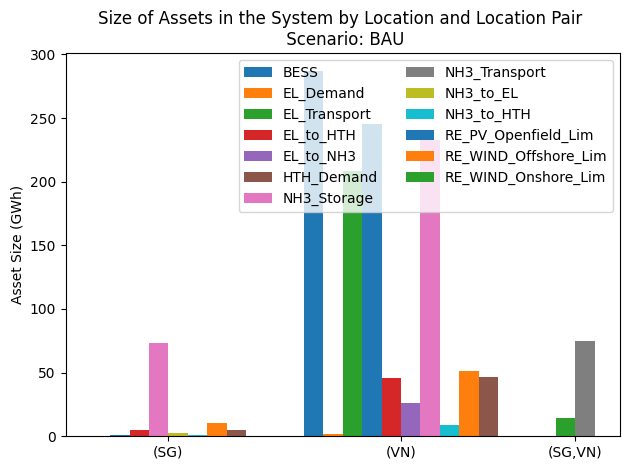

In [6]:
my_artist = df_results.loc[len(df_results)-1, "artist"]

bar_width = 1.0
bar_spacing = 3.0
my_artist.plot(bar_width, bar_spacing)

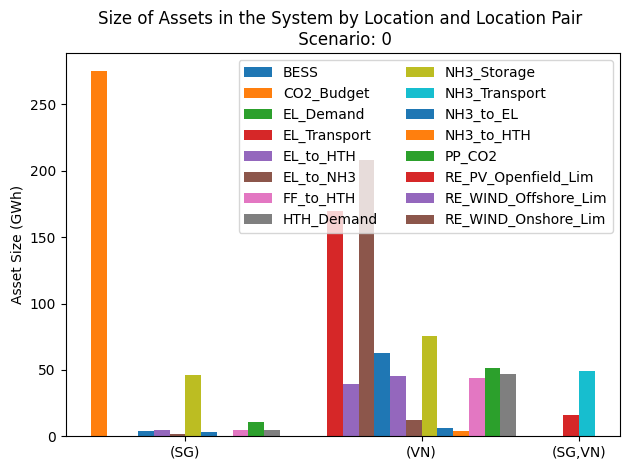

In [7]:
my_artist = df_results.loc[0, "artist"]

bar_width = 1.0
bar_spacing = 3.0
my_artist.plot(bar_width, bar_spacing)

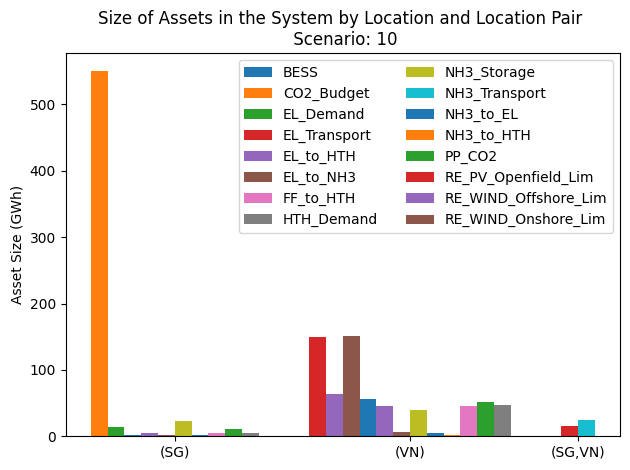

In [8]:
my_artist = df_results.loc[1, "artist"]

bar_width = 1.0
bar_spacing = 3.0
my_artist.plot(bar_width, bar_spacing)

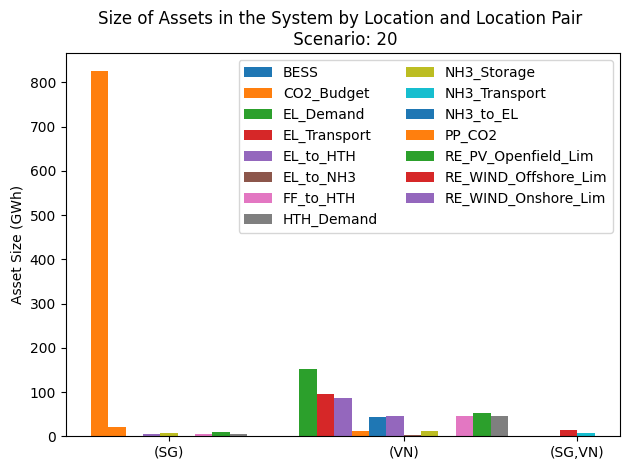

In [9]:
my_artist = df_results.loc[2, "artist"]

bar_width = 1.0
bar_spacing = 3.0
my_artist.plot(bar_width, bar_spacing)

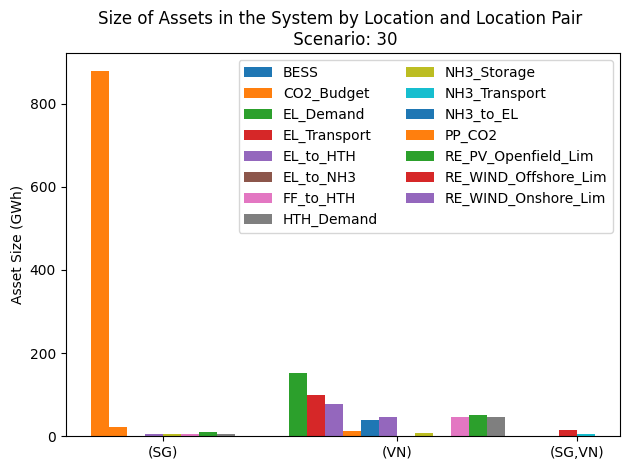

In [10]:
my_artist = df_results.loc[3, "artist"]

bar_width = 1.0
bar_spacing = 3.0
my_artist.plot(bar_width, bar_spacing)

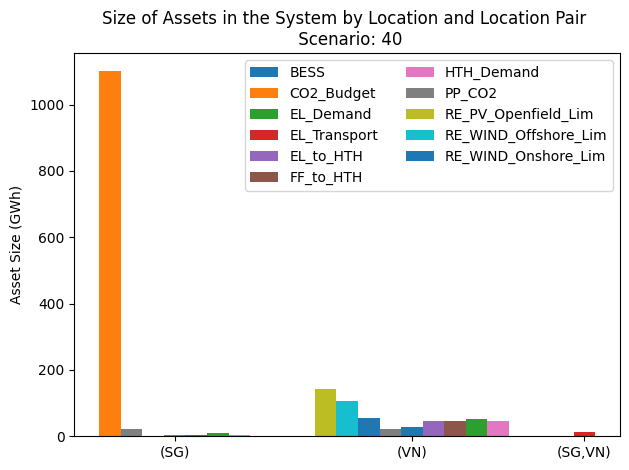

In [11]:
my_artist = df_results.loc[4, "artist"]

bar_width = 1.0
bar_spacing = 3.0
my_artist.plot(bar_width, bar_spacing)

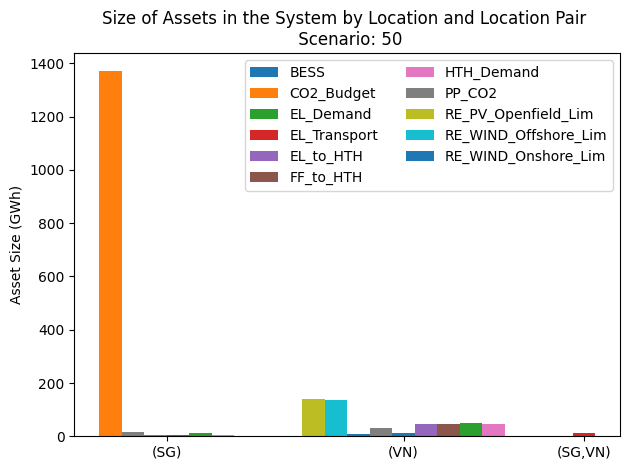

In [12]:
my_artist = df_results.loc[5, "artist"]

bar_width = 1.0
bar_spacing = 3.0
my_artist.plot(bar_width, bar_spacing)

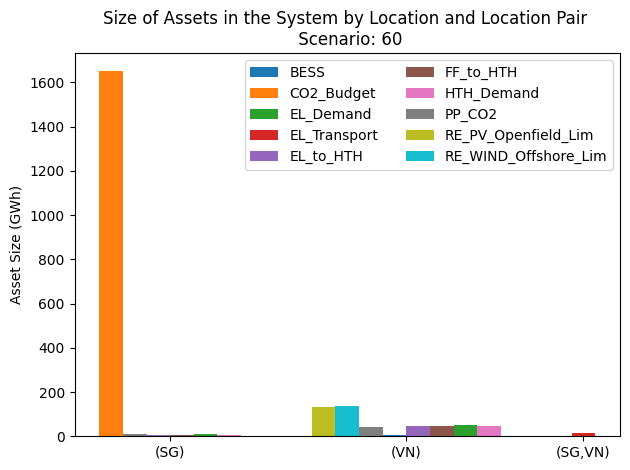

In [13]:
my_artist = df_results.loc[6, "artist"]

bar_width = 1.0
bar_spacing = 3.0
my_artist.plot(bar_width, bar_spacing)

In [14]:
my_artist = df_results.loc[6, "artist"]

bar_width = 1.0
bar_spacing = 3.0
my_artist.plot(bar_width, bar_spacing)

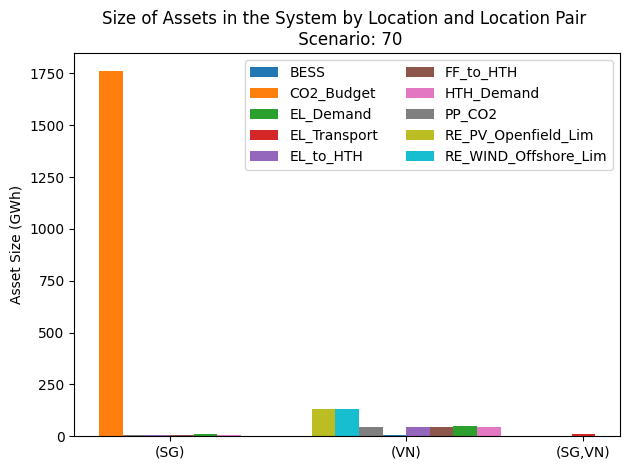

In [15]:
my_artist = df_results.loc[7, "artist"]

bar_width = 1.0
bar_spacing = 3.0
my_artist.plot(bar_width, bar_spacing)

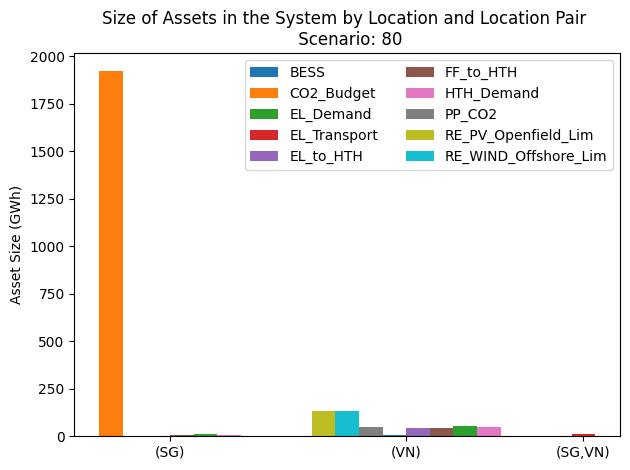

In [16]:
my_artist = df_results.loc[8, "artist"]

bar_width = 1.0
bar_spacing = 3.0
my_artist.plot(bar_width, bar_spacing)

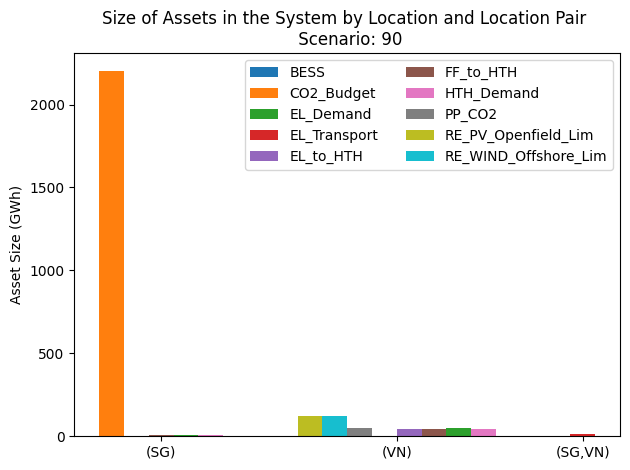

In [17]:
my_artist = df_results.loc[9, "artist"]

bar_width = 1.0
bar_spacing = 3.0
my_artist.plot(bar_width, bar_spacing)